In [1]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import norm, skew
from omegaconf import OmegaConf
from config import py_config

In [2]:
test = pd.read_csv(py_config.paths.test)
train = pd.read_csv(py_config.paths.train)

X = train.drop(columns = ['SalePrice', 'Id'])
y = train['SalePrice']

X_test = test.drop(columns=['Id'])
# y.head(20)
# test.head(20)

In [3]:
# train.columns
num_columns = X.select_dtypes(include=['number']).columns.to_list()
cat_columns = X.select_dtypes(exclude=['number']).columns.to_list()
print(len(num_columns), len(cat_columns))

36 43


In [4]:
def missing_value(df):
    r = df.isna().mean().sort_values(ascending=False)
    r = r[r > 0]
    return pd.DataFrame({"missing_rate": r, "missing_cnt": df.isna().sum()[r.index]})

missing_value(X).head(20)


,missing_rate,missing_cnt
PoolQC,0.995205,1453
MiscFeature,0.963014,1406
Alley,0.937671,1369
Fence,0.807534,1179
MasVnrType,0.597260,872
FireplaceQu,0.472603,690
LotFrontage,0.177397,259
GarageCond,0.055479,81
GarageType,0.055479,81
GarageYrBlt,0.055479,81


Удаляем константы

In [5]:
const_cols = [c for c in X.columns if X[c].nunique(dropna=False) < 1]
X = X.drop(columns=const_cols)
X_test = X_test.drop(columns=const_cols)

num_columns = X.select_dtypes(include=['number']).columns.to_list()
cat_columns = X.select_dtypes(exclude=['number']).columns.to_list()
print(len(num_columns), len(cat_columns))


36 43


In [6]:
train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


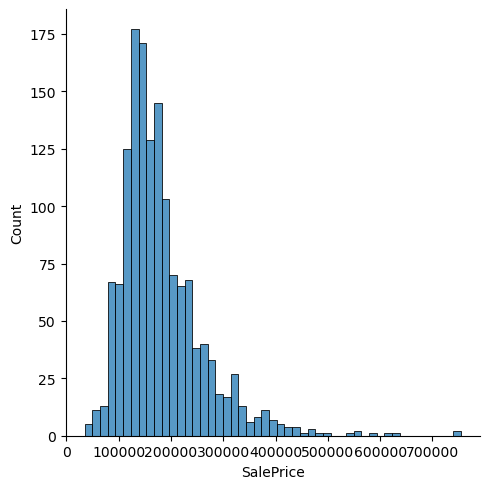

In [8]:
sns.displot(train['SalePrice'])

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

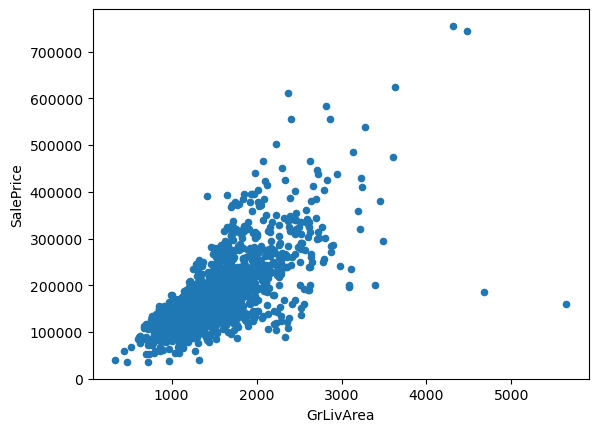

In [9]:
var = 'GrLivArea'
data = pd.concat([train['SalePrice'], train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=0.000)

In [10]:
train = train.drop(train[(train['SalePrice'] <= 300_000) & (train['GrLivArea'] >= 4_000)].index)

In [11]:
data = pd.concat([train['SalePrice'], train['GrLivArea']], axis=1)
data.head(20)
# data.plot.scatter(x=var, y='SalePrice', ylim=0.000)


,SalePrice,GrLivArea
0,208500,1710
1,181500,1262
2,223500,1786
3,140000,1717
4,250000,2198
5,143000,1362
6,307000,1694
7,200000,2090
8,129900,1774
9,118000,1077


In [12]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


 mu = 180932.92 and sigma = 79467.79



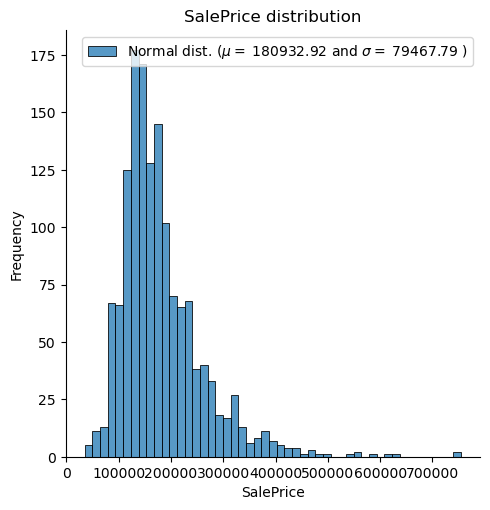

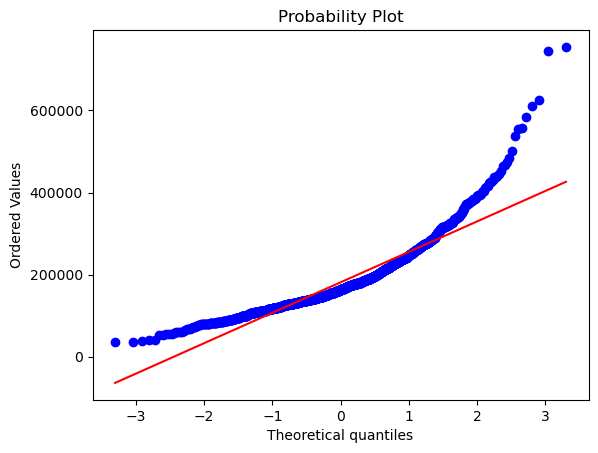

In [13]:
sns.displot(train['SalePrice'])
(mu, sigma) = norm.fit(train['SalePrice'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

#Now plot the distribution
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

#Get also the QQ-plot
fig = plt.figure()
res = stats.probplot(train['SalePrice'], plot=plt)
plt.show()

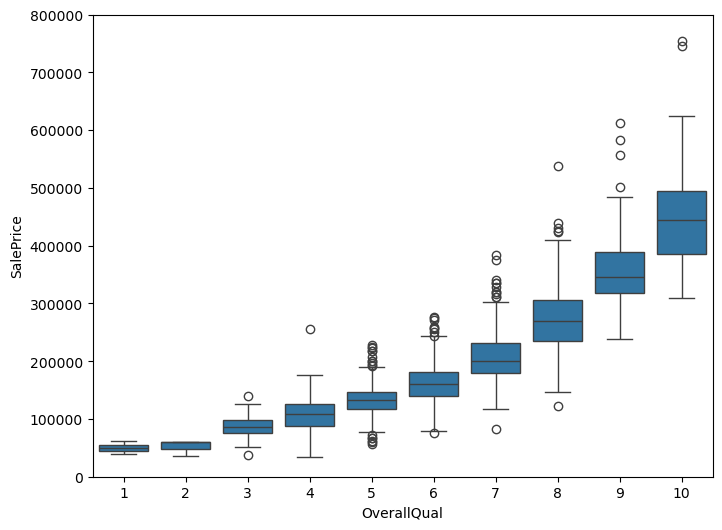

In [14]:
#box plot overallqual/saleprice
var = 'OverallQual'
data = pd.concat([train['SalePrice'], train[var]], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);

In [ ]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score, StratifiedGroupKFold
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier

import xgboost as xgb
import lightgbm as gbm
from lightgbm import LGBMClassifier

In [16]:
non_cat = [
    "Alley", "Fence", "FireplaceQu", "PoolQC", 
    "MiscFeature", "BsmtQual", "BsmtCond", 
    "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "GarageType", "GarageFinish", "GarageQual", 
    "GarageCond", "MasVnrType"
]

zero_num = [
    "GarageCars", "GarageArea", "BsmtFinSF1",
    "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath"
]

non_cat = [c for c in X.columns if c not in zero_num]
zero_num = [c for c in X.columns if c not in non_cat]
# non_cat

other_cat = [c for c in cat_columns if c not in non_cat]
other_num = [c for c in num_columns if c not in zero_num]

Здесь мы избавляемся от пропусков/заполняем "не пропуски" так чтобы модель могла их отличить от пропусков
- это поможет сделать валидацию без утечек

In [17]:
num_zero_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

num_other_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])

cat_non_pipe = Pipeline(steps=[
    ('imput', SimpleImputer(strategy='constant', fill_value=None)),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

cat_other_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', add_indicator=True)),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])


preprocess_linear = ColumnTransformer(
    transformers=[
        ('num0', num_zero_pipe, num_columns),
        ('num', num_other_pipe, num_columns),
        ('catN', cat_non_pipe, cat_columns),
        ('cat', cat_other_pipe, cat_columns)
    ],
remainder='drop'
)

In [18]:
def rmsle(y_true, y_pred):
    y_true = np.maximum(y_true, 0)
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

rmsle_scorer = make_scorer(rmsle, greater_is_better=False) # -> тут нам важно минимизировать лосс - поэтому False

In [ ]:
MODEL_REGISTRY = {
    'LogisticRegression': LogisticRegression,
    'RandomForestClassifier': RandomForestClassifier,
    'ExtraTreesClassifier': ExtraTreesClassifier,
    'HistGradientBoostingClassifier': HistGradientBoostingClassifier,
    'XGBClassifier': xgb.XGBClassifier,
    'Ridge': Ridge,
    'LightGBM': gbm.LGBMClassifier
}
# Combination model + param - instance
def build_models(py_config):
    models = {}
    names = py_config.model.types
    if names is None:
        raise ValueError('ModelType is not found in config')

    for name in names:
        cls = MODEL_REGISTRY[name]
        param_cfg = py_config.model.params.get(name, {})
        param = OmegaConf.to_container(param_cfg, resolve=True) # Перевели из Dict.conf -> dict
        models[name] = cls(**param)
    return models

In [20]:
"""Baseline - Ridge"""

'Baseline - Ridge'

In [21]:
base = Ridge(alpha=20.0, random_state=42)

model = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ("preprocess", preprocess_linear),
        ("model", base)
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, scoring=rmsle_scorer, cv=cv)

print("CV RMSLE:", -scores.mean(), "+/-", scores.std())

CV RMSLE: 0.14688166187711177 +/- 0.03926301241589614
